In [1]:
import os
BASE_DIR = os.getcwd()
SRC_DIR = os.path.join(BASE_DIR, "src2")
from src2.agregation import aggregate_data
from src2.regression import built_model
from src2.visualisations import conso_date, conso_temp, conso_precip, conso_jour, predictions, residus

# Prédire la consommation d'électricité

Nous souhaitons prédire la consommation d'électricité journalière en France Métropolitaine à partir de données agrégées de différentes sources publiques : 

- consommation nationale d'électricité  journalière via l'API RTE
- température journalière (moyenne de 30 villes dispersées sur le territoire métropolitain) via l'API Open-Meteo
- précipitaitons journalière (moyenne de 30 villes dispersées sur le territoire métropolitain) via l'API Open-Meteo
- jours ouvrés et non ouvrés via l'API data.gouv

Nous visualisons nos données avant de construire un modèle explicatif pour prédire cette consommation journalière. 

## Données

La fonction aggregate_data() agrège trois fichiers .csv : chacun construit via une fonction récupérant les données des API. Ces trois fichiers ne sont pas reconstruits à l'appel de la fonction aggregate_data() pour une question de temps d'éxécution. 

In [2]:
aggregate_data().head()

,date,consommation,temperature,precipitation,is_non_ouvre
0,2012-01-01,2471592.0,11.390000,2.120000,1
1,2012-01-02,2912815.0,8.503333,8.546667,0
2,2012-01-03,3252581.0,7.983333,2.730000,0
3,2012-01-04,3265403.0,7.976667,4.803333,0
4,2012-01-05,3319555.0,8.673333,6.590000,0


Nous souhaitons désormais visualiser les relations entre nos variables explicatives et notre variable cible : la consommation d'électricité. 

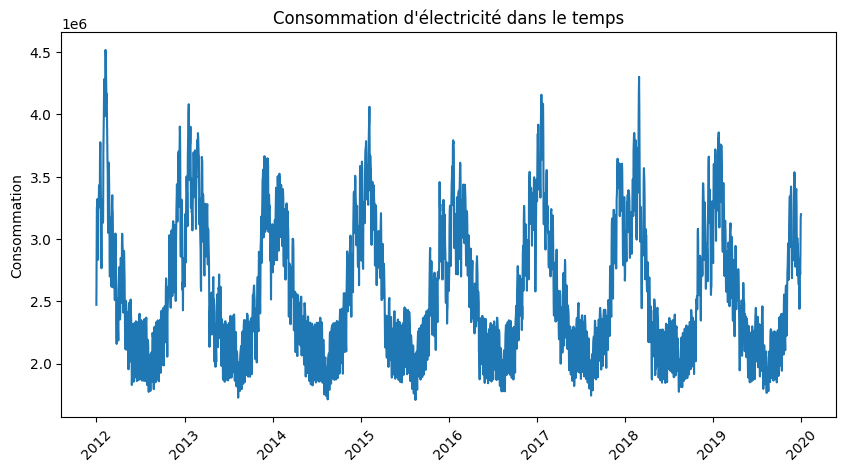

In [3]:
conso_date()


Ce n'est pas surprenant : la consommation d'électricité est saisonnière !

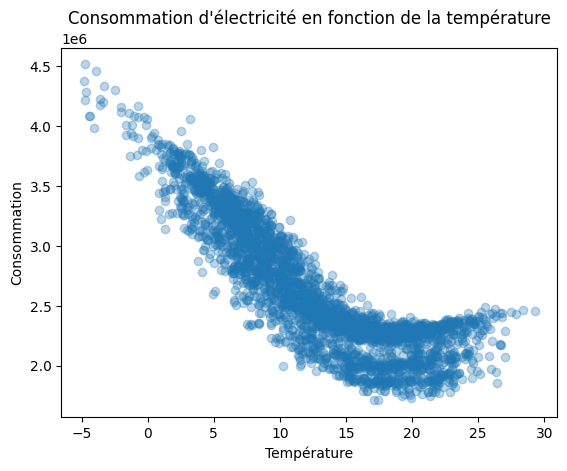

In [4]:
conso_temp()

La consommation est corrélée de façon non-linéaire à la température :
- à partir d'une quinzaine de degrés, elle augmente au fûr-et-à-mesure que la température descend 
- au dessus d'une quinzaine de degrés, elle semble stagne

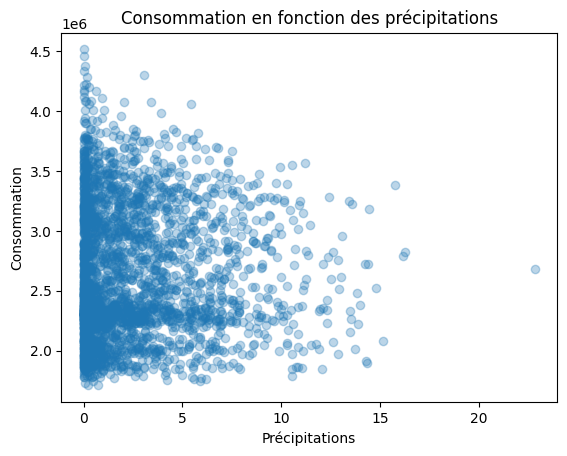

In [5]:
conso_precip()

La consommation d'électricité ne semble pas corrélée aux précipitations. 

<Figure size 600x400 with 0 Axes>

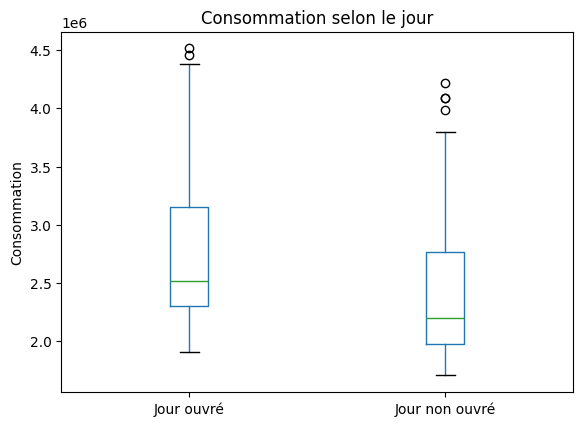

stat: 1295273.0
p-value: 8.153775302182951e-73


In [6]:
conso_jour()

La consommation d'électricité est significativement plus élevée les jours ouvrés, on suppose que cela est dû à l'activité économique. 

## Prédictions

Du fait de la non-linéarité entre la consommation et la température, et de la nature de la variable "is_non_ouvre", nous décidons d'estimer la consommation d'électricité via une forêt aléatoire.

In [7]:
model = built_model()

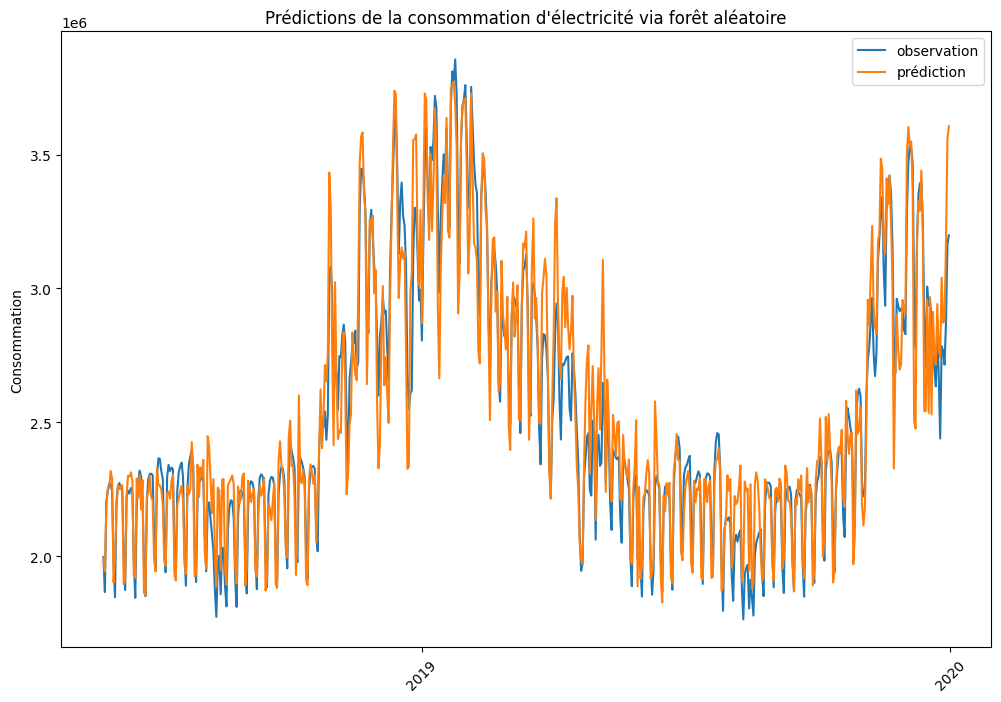

In [8]:
predictions()

In [9]:
model["R2"]

0.9101527574667488

Le modèle semble très correctement estimer la consommation d'électricité même s'il ne peut pas anticiper tous les chocs de consommation ! 

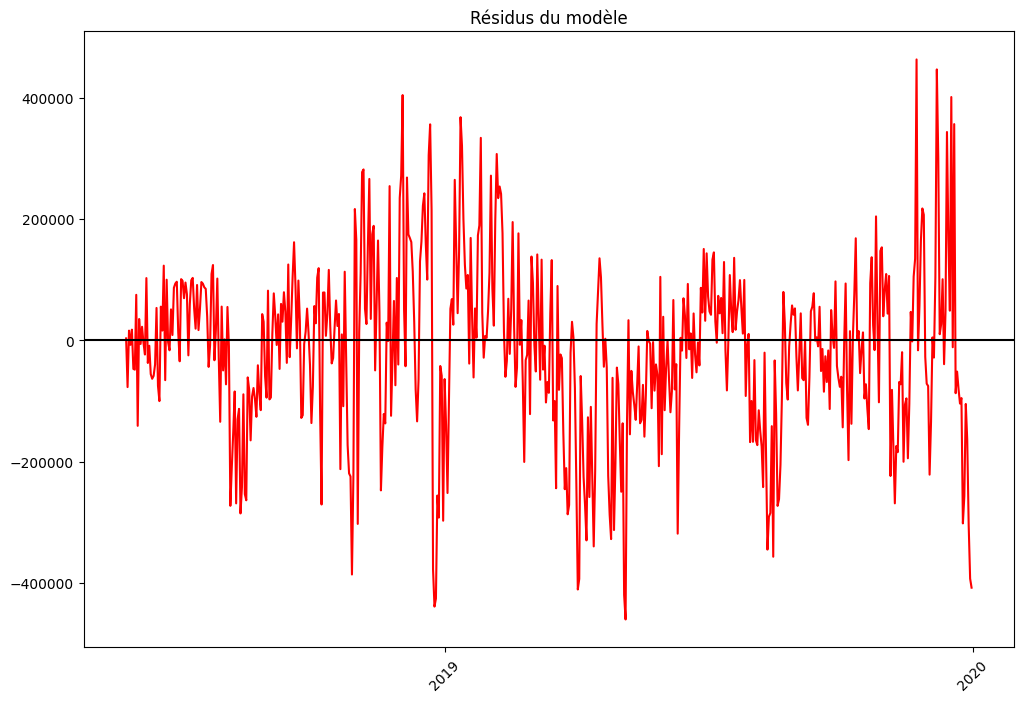

In [10]:
residus()

Les résidus oscillent autour de 0 la majorité du temps donc il n'invalident pas notre modèle. 